In [1]:
# Basic
import numpy as np
import scipy
import scipy.stats
from scipy.stats import ttest_rel, ttest_1samp
from scipy.stats import pearsonr
from statsmodels.stats.multitest import fdrcorrection
import os
import itertools
from itertools import combinations
import warnings
import sys
from copy import deepcopy

# Data Loading
import cmlreaders as cml #Penn Computational Memory Lab's library of data loading functions

# Data Handling
import os
from os import listdir as ld
import os.path as op
from os.path import join, exists as ex
import time
import datetime

# Data Analysis
import pandas as pd
import xarray as xr

# EEG & Signal Processing
import ptsa
from ptsa.data.readers import BaseEventReader, EEGReader, CMLEventReader, TalReader
from ptsa.data.filters import MonopolarToBipolarMapper, MorletWaveletFilter
from ptsa.data.timeseries import TimeSeries

# Data Visualization
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
%matplotlib inline
import seaborn as sns

# Parallelization
import cmldask.CMLDask as da
from cmldask.CMLDask import new_dask_client_slurm as cl
from cluster import wait, get_exceptions_quiet as get_ex
import cmldask

%load_ext autoreload
%autoreload 2

from cstat import * 
from misc import *

USERNAME = get_username_from_working_directory(index=2)
root_dir = f'/scratch/{USERNAME}/fc_comparison_dir'

if not os.path.exists(root_dir):
    os.makedirs(root_dir)

import helper
from helper import *
helper.root_dir = root_dir

from pathlib import Path
from tqdm.auto import tqdm

from functools import partial
cluster_log_dir = 'cluster'
cl = partial(cl, log_directory=cluster_log_dir)
if not os.path.exists(cluster_log_dir):
    os.mkdir(cluster_log_dir)

figure_path = 'figures'
if not os.path.exists(figure_path):
    os.mkdir(figure_path)

font_dirs = ['fonts']

warnings.filterwarnings(action='ignore', message='Mean of empty slice')
warnings.filterwarnings(action='ignore', message='DataFrame is highly fragmented')

from mne_connectivity import spectral_connectivity_epochs
import fc_comparison_functions as fc
import re

/home1/jueenaik/miniforge3/envs/mod_workshop_311/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
/home1/jueenaik/miniforge3/envs/mod_workshop_311/lib/python3.11/site-packages/ptsa/data/readers/__init__.py:16: FutureWarning: PTSA readers will be removed in a future release. Please consider using the cmlreaders package instead: https://github.com/pennmem/cmlreaders
  warnings.warn(


In [3]:
sess_list_df = pd.read_json(join(root_dir, "sess_list_df.json")).query("include == True")

In [4]:
sess_counts = sess_list_df.groupby("exp").size()
sess_counts.sort_values(ascending=False)

exp
catFR1    433
FR1       389
pyFR      142
dtype: int64

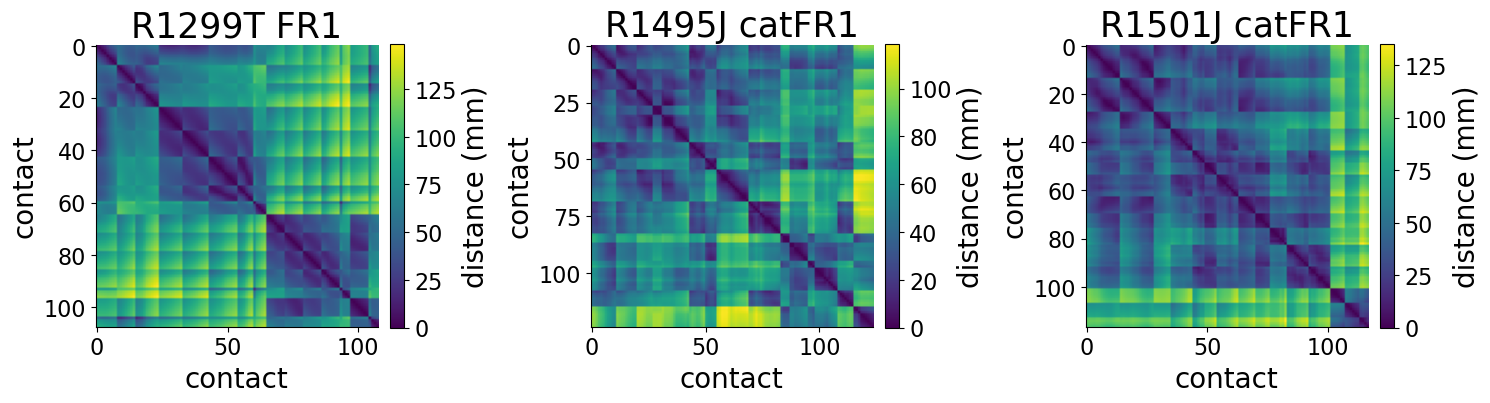

In [5]:
from scipy.spatial.distance import pdist, squareform
from project_paths import SCRATCH_DIR
helper.root_dir = str(SCRATCH_DIR)

SUBS_8 = [("R1299T", "FR1"), ("R1495J", "catFR1"), ("R1501J", "catFR1")]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, (sub, exp) in zip(axes, SUBS_8):
    dfrow = pd.Series({"sub": sub, "exp": exp, "sess": 0, "loc": 0, "mon": 0})
    p = helper.get_pairs(dfrow)
    xyz = p[["avg.x", "avg.y", "avg.z"]].apply(pd.to_numeric, errors="coerce").to_numpy()
    D = squareform(pdist(xyz))                      
    im = ax.imshow(D, cmap="viridis", aspect="equal")
    ax.set_title(f"{sub} {exp}")
    ax.set_xlabel("contact"); ax.set_ylabel("contact")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="distance (mm)")
fig.tight_layout(); plt.show()


In [7]:
sub, exp, sess = "R1495J", "catFR1", 0          
dfrow = pd.Series({"sub": sub, "exp": exp, "sess": sess, "loc": 0, "mon": 0})
p = helper.get_pairs(dfrow)

contacts = pd.unique(p[["contact_label_1", "contact_label_2"]].values.ravel())

def split_lead(c):                            
    m = re.match(r"^(.*?)(\d+)$", str(c))
    return (m.group(1), int(m.group(2))) if m else (str(c), -1)

cdf = pd.DataFrame([(*split_lead(c), c) for c in contacts],
                   columns=["electrode", "num", "contact"]).sort_values(["electrode", "num"])

summary = (cdf.groupby("electrode")
              .agg(n_contacts=("contact", "size"),
                   contacts=("contact", lambda s: ", ".join(s)))
              .reset_index())

pd.set_option("display.max_colwidth", None)
print(f"{sub} {exp}: {len(summary)} electrodes, {len(contacts)} contacts")
summary


R1495J catFR1: 13 electrodes, 138 contacts


,electrode,n_contacts,contacts
0,ROb,18,"ROb1, ROb2, ROb3, ROb4, ROb5, ROb6, ROb7, ROb8, ROb9, ROb10, ROb11, ROb12, ROb13, ROb14, ROb15, ROb16, ROb17, ROb18"
1,ROc,15,"ROc1, ROc2, ROc3, ROc4, ROc5, ROc6, ROc7, ROc8, ROc9, ROc10, ROc11, ROc12, ROc13, ROc14, ROc15"
2,RP,5,"RP1, RP2, RP3, RP4, RP5"
3,RPc,10,"RPc1, RPc2, RPc3, RPc4, RPc5, RPc6, RPc7, RPc8, RPc9, RPc10"
4,RQa,10,"RQa1, RQa2, RQa3, RQa4, RQa5, RQa6, RQa7, RQa8, RQa9, RQa10"
5,RQb,8,"RQb1, RQb2, RQb3, RQb4, RQb5, RQb6, RQb7, RQb8"
6,RS,14,"RS1, RS2, RS3, RS4, RS5, RS7, RS8, RS9, RS10, RS11, RS12, RS13, RS14, RS15"
7,RT,15,"RT1, RT2, RT3, RT4, RT5, RT6, RT7, RT8, RT9, RT10, RT11, RT12, RT13, RT14, RT15"
8,RWa,8,"RWa1, RWa2, RWa3, RWa4, RWa5, RWa6, RWa7, RWa8"
9,RWb,5,"RWb1, RWb2, RWb3, RWb4, RWb5"


In [35]:
sub, exp, sess = "R1495J", "catFR1", 0
electrode_name = "RQa"
rmin, rmax     = 20.0, 50.0

dfrow = pd.Series({"sub": sub, "exp": exp, "sess": sess, "loc": 0, "mon": 0})
p0   = helper.get_pairs(dfrow)
xyz  = p0[["avg.x", "avg.y", "avg.z"]].apply(pd.to_numeric, errors="coerce").to_numpy()
lead = p0["label"].str.extract(r"^([A-Za-z]+)")[0]

def contacts_of(label):
    return set(label.split("-"))

def disjoint_targets(seed_idx, cand_idx):
    used = set(contacts_of(p0["label"][seed_idx]))
    keep = []
    for j in cand_idx:
        c = contacts_of(p0["label"][j])
        if c & used:
            continue
        keep.append(j)
        used |= c
    return keep

tgt = {}
for s in p0.index[lead == electrode_name]:
    cand = [j for j in range(len(p0))
            if j != s and rmin <= np.linalg.norm(xyz[j] - xyz[s]) <= rmax]
    tgt[s] = disjoint_targets(s, cand)
seeds = [s for s in tgt if tgt[s]]

el_idx = [i for i in p0.index[lead == electrode_name]]
print(p0.loc[el_idx, ["label", "ind.region", "mni.region"]].to_string())
for s in seeds: print(p0['label'][s], "->", list(p0['label'][tgt[s]]))

         label        ind.region                          mni.region
74   RQa1-RQa2  inferiortemporal            Right FuG fusiform gyrus
75   RQa2-RQa3  inferiortemporal            Right FuG fusiform gyrus
76   RQa3-RQa4  inferiortemporal         Right Cerebral White Matter
77   RQa4-RQa5  inferiortemporal            Right FuG fusiform gyrus
78   RQa5-RQa6  inferiortemporal   Right ITG inferior temporal gyrus
79   RQa6-RQa7  inferiortemporal         Right Cerebral White Matter
80   RQa7-RQa8    middletemporal     Right MTG middle temporal gyrus
81   RQa8-RQa9    middletemporal         Right Cerebral White Matter
82  RQa9-RQa10    middletemporal         Right Cerebral White Matter
RQa1-RQa2 -> ['Ri1-Ri2', 'Ri3-Ri4', 'Ri5-Ri6', 'Ri7-Ri8', 'Rm1-Rm2', 'Rm3-Rm4', 'Rm5-Rm6', 'Rk1-Rk2', 'Rk3-Rk4', 'ROb1-ROb2', 'ROb3-ROb4', 'RWa1-RWa2', 'RWa3-RWa4', 'RWa5-RWa6', 'RWa7-RWa8', 'RWb1-RWb2', 'ROc1-ROc2', 'RP4-RP5', 'RQa7-RQa8', 'RQa9-RQa10', 'RQb1-RQb2', 'RQb3-RQb4', 'RQb5-RQb6', 'RQb7-RQb8']
RQa

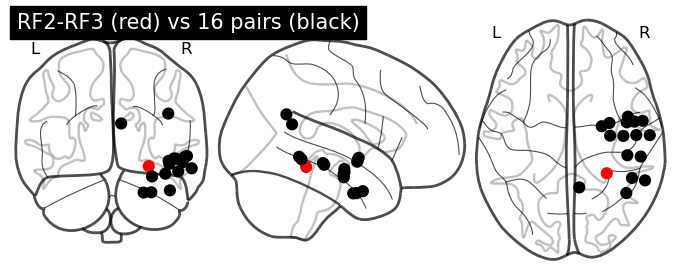

In [6]:
from nilearn import plotting

p0 = helper.get_pairs(pd.Series({"sub":"R1299T","exp":"FR1","sess":0,"loc":0,"mon":0}))  

target = "RF2-RF3"
others = ['RI1-RI2','RI3-RI4','RI7-RI8','RB1-RB2','RB3-RB4','RB5-RB6','RB7-RB8',
          'RC4-RC5','RC6-RC7','RF6-RF7','RF8-RF9','RX1-RX2','RX7-RX8',
          'RT1-RT2','RT3-RT4','RT5-RT6']

coord = p0.set_index("label")[["avg.x","avg.y","avg.z"]].apply(pd.to_numeric, errors="coerce")
sel    = [l for l in [target] + others if l in coord.index and coord.loc[l].notna().all()]
coords = coord.loc[sel].to_numpy(float)
colors = ["red"] + ["black"] * (len(sel) - 1)

adj = np.zeros((len(sel), len(sel)))                       
plotting.plot_connectome(adj, coords, node_color=colors, node_size=60,
                         display_mode="ortho",
                         title=f"{target} (red) vs {len(sel)-1} pairs (black)")
plotting.show()


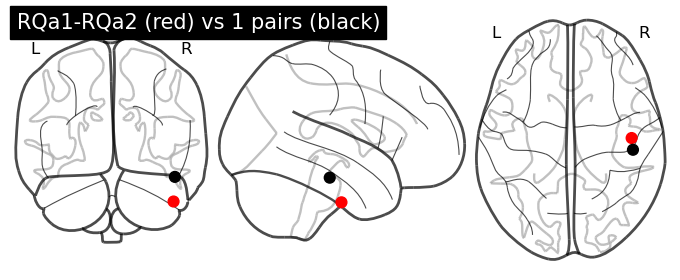

In [25]:
from nilearn import plotting

p0 = helper.get_pairs(pd.Series({"sub":"R1495J","exp":"catFR1","sess":0,"loc":0,"mon":0}))  

target = "RQa1-RQa2"
others = ['RQb1-RQb2']

coord = p0.set_index("label")[["avg.x","avg.y","avg.z"]].apply(pd.to_numeric, errors="coerce")
sel    = [l for l in [target] + others if l in coord.index and coord.loc[l].notna().all()]
coords = coord.loc[sel].to_numpy(float)
colors = ["red"] + ["black"] * (len(sel) - 1)

adj = np.zeros((len(sel), len(sel)))                       
plotting.plot_connectome(adj, coords, node_color=colors, node_size=60,
                         display_mode="ortho",
                         title=f"{target} (red) vs {len(sel)-1} pairs (black)")
plotting.show()

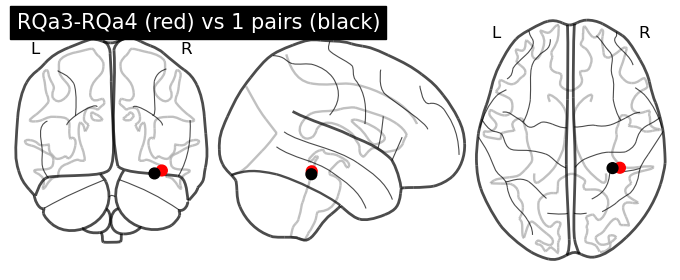

In [5]:
from nilearn import plotting

p0 = helper.get_pairs(pd.Series({"sub":"R1495J","exp":"catFR1","sess":0,"loc":0,"mon":0}))  

target = "RQa3-RQa4"
others = ['RQa1-RQa2']

coord = p0.set_index("label")[["mni.x","mni.y","mni.z"]].apply(pd.to_numeric, errors="coerce")
sel    = [l for l in [target] + others if l in coord.index and coord.loc[l].notna().all()]
coords = coord.loc[sel].to_numpy(float)
colors = ["red"] + ["black"] * (len(sel) - 1)

adj = np.zeros((len(sel), len(sel)))                       
plotting.plot_connectome(adj, coords, node_color=colors, node_size=60,
                         display_mode="ortho",
                         title=f"{target} (red) vs {len(sel)-1} pairs (black)")
plotting.show()

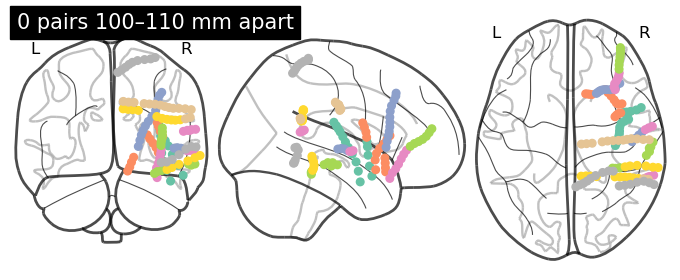

In [7]:
from itertools import combinations

C = p0.set_index("label")[["mni.x","mni.y","mni.z"]].apply(pd.to_numeric, errors="coerce").dropna()
labels = C.index.to_list()
xyz = C.to_numpy(float)

D = np.linalg.norm(xyz[:, None, :] - xyz[None, :, :], axis=2)
adj = np.zeros_like(D)
i = labels.index(target)
mask = (D[i] >= 100) & (D[i] <= 110)
adj[i, mask] = adj[mask, i] = 1.0

np.fill_diagonal(adj, 0)

n_edges = int(adj.sum() // 2)
plotting.plot_connectome(adj, xyz, node_size=30, edge_cmap="autumn",
                         display_mode="ortho",
                         title=f"{n_edges} pairs 100–110 mm apart")
plotting.show()


# 6-12 Hz

       label        ind.region        avg.region                          wb.region
86   RF1-RF2          fusiform   parahippocampal           Right FuG fusiform gyrus
87   RF2-RF3          fusiform   parahippocampal           Right FuG fusiform gyrus
88   RF3-RF6          fusiform          fusiform                                nan
89   RF6-RF7  inferiortemporal  inferiortemporal        Right Cerebral White Matter
90   RF7-RF8  inferiortemporal    middletemporal  Right ITG inferior temporal gyrus
91   RF8-RF9    middletemporal    middletemporal    Right MTG middle temporal gyrus
92  RF9-RF10    middletemporal    middletemporal    Right MTG middle temporal gyrus
RF1-RF2 -> ['RF9-RF10']
RF3-RF6 -> ['RT1-RT2']
RF9-RF10 -> ['RB4-RB5', 'RC1-RC2', 'RF1-RF2']


/tmp/ipykernel_302710/2769747386.py:79: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  X, freqs, w = psd_array_multitaper(
/tmp/ipykernel_302710/2769747386.py:79: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  X, freqs, w = psd_array_multitaper(
/tmp/ipykernel_302710/2769747386.py:79: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  X, freqs, w = psd_array_multitaper(
/tmp/ipykernel_302710/2769747386.py:79: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  X, freqs, w = psd_array_multitaper(
/tmp/ipykernel_302710/2769747386.py:79: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  X, freqs, w = psd_array_multitaper(
/tmp/ipykernel_302710/2769747386.py:79: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  X, freqs, w = psd_array_multitaper(
/tmp/ipykernel_302710/2769747386.py:79: RuntimeWarning: Could not properly use low

RF1-RF2 [all sessions (7, per-event)]  PLV Δ=+0.047 p=3.3e-02  PPC Δ=+0.005 p=3.0e-02  ciPLV Δ=+0.032 p=1.6e-01  PLI Δ=+0.023 p=4.9e-01


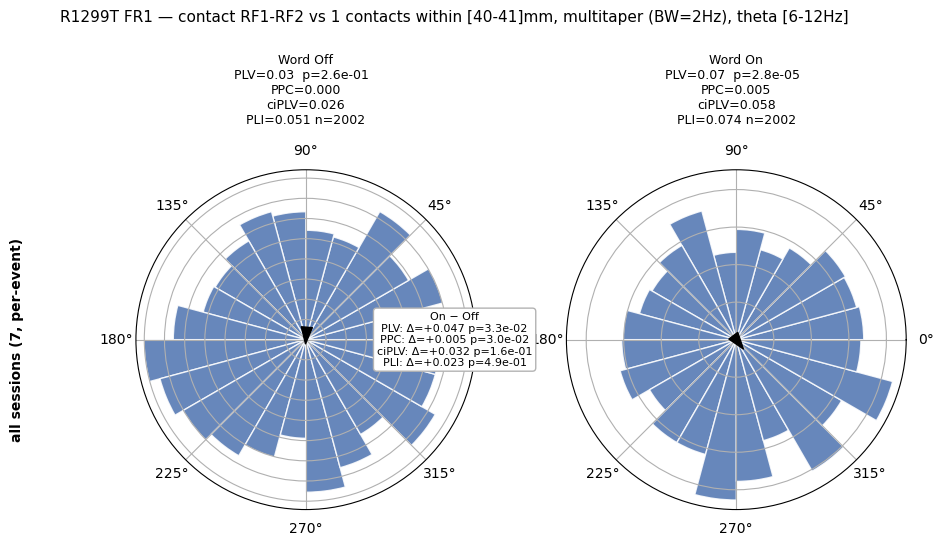

RF3-RF6 [all sessions (7, per-event)]  PLV Δ=+0.012 p=5.5e-01  PPC Δ=+0.002 p=5.5e-01  ciPLV Δ=+0.015 p=4.7e-01  PLI Δ=+0.028 p=3.6e-01


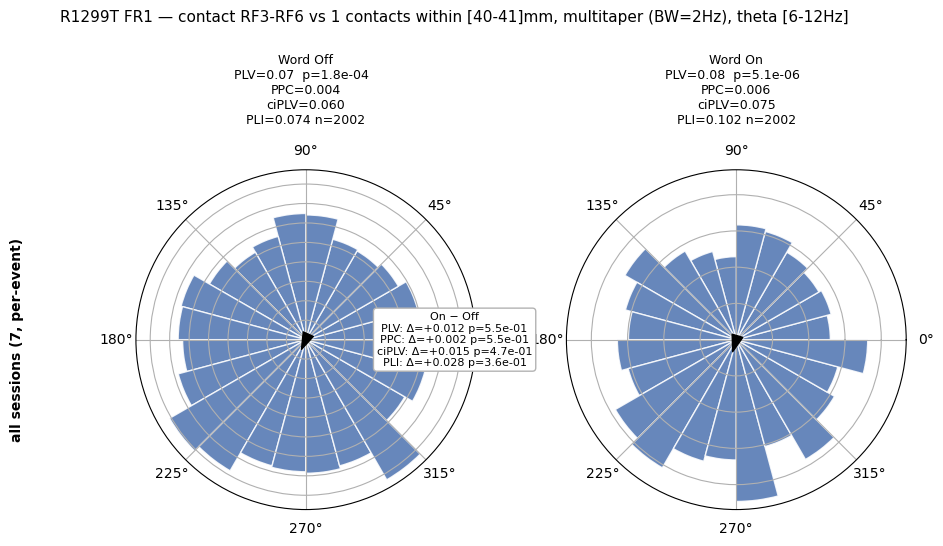

RF9-RF10 [all sessions (7, per-event)]  PLV Δ=-0.003 p=8.9e-01  PPC Δ=-0.000 p=8.9e-01  ciPLV Δ=+0.018 p=4.2e-01  PLI Δ=+0.019 p=5.9e-01


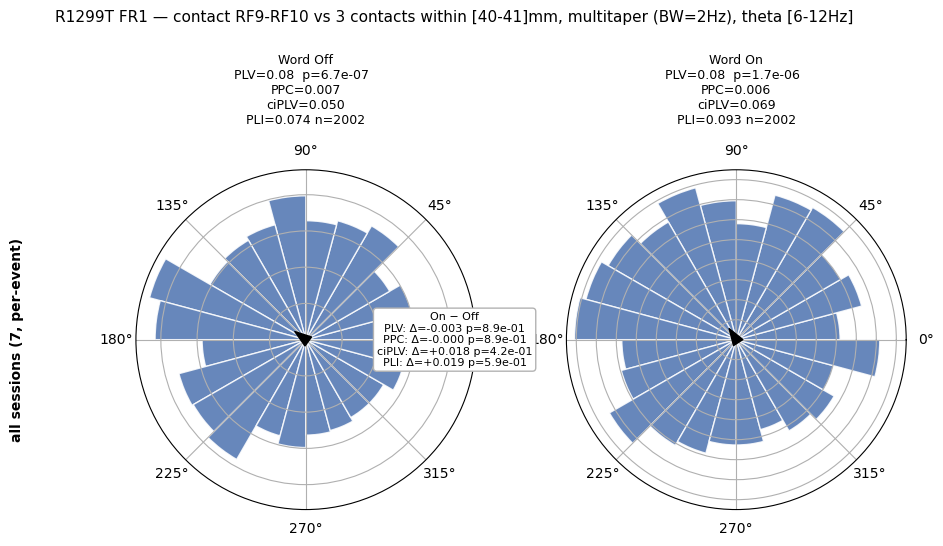

In [ ]:
from mne.time_frequency import psd_array_multitaper
import cstat

sub, exp, sess = "R1299T", "FR1", 0
electrode_name = "RF"
rmin, rmax     = 40,41
fmin, fmax     = (6.0, 12.0)     
mt_bandwidth   = 2.0                   
pre_win, post_win = (-700., -100.), (0., 600.)
n_bins = 24

dfrow = pd.Series({"sub": sub, "exp": exp, "sess": sess, "loc": 0, "mon": 0})
p0   = helper.get_pairs(dfrow)
xyz  = p0[["avg.x", "avg.y", "avg.z"]].apply(pd.to_numeric, errors="coerce").to_numpy()
lead = p0["label"].str.extract(r"^([A-Za-z]+)")[0]

def contacts_of(label):
    return set(label.split("-"))

def disjoint_targets(seed_idx, cand_idx):
    used = set(contacts_of(p0["label"][seed_idx]))
    keep = []
    for j in cand_idx:
        c = contacts_of(p0["label"][j])
        if c & used:
            continue
        keep.append(j)
        used |= c
    return keep

tgt = {}
for s in p0.index[lead == electrode_name]:
    cand = [j for j in range(len(p0))
            if j != s and rmin <= np.linalg.norm(xyz[j] - xyz[s]) <= rmax]
    tgt[s] = disjoint_targets(s, cand)
seeds = [s for s in tgt if tgt[s]]

el_idx = [i for i in p0.index[lead == electrode_name]]
print(p0.loc[el_idx, ["label", "ind.region", "avg.region", "wb.region"]].to_string())
for s in seeds: print(p0['label'][s], "->", list(p0['label'][tgt[s]]))

sessions = [s for s in range(9)
            if helper.load_events(pd.Series({"sub": sub, "exp": exp, "sess": s, "loc": 0, "mon": 0}), "word_on") is not None]

METRICS = ["PLV", "PPC", "ciPLV", "PLI"]

def cons(ang, metric):
    ang = np.asarray(ang); ang = ang[np.isfinite(ang)]
    n = ang.size
    if n < 2: return np.nan
    z = np.exp(1j * ang); R = abs(z.mean())
    if metric == "PLV":   return R
    if metric == "PPC":   return (n * R * R - 1) / (n - 1)
    re, im = z.real.mean(), z.imag.mean()
    if metric == "ciPLV": return abs(im) / np.sqrt(max(1 - re * re, 1e-12))
    if metric == "PLI":   return abs(np.sign(z.imag).mean())

def paired_perm(off, on, n_perm=1000, seed=0):
    rng = np.random.default_rng(seed)
    off, on = np.asarray(off, float), np.asarray(on, float)
    obs = {m: cons(on, m) - cons(off, m) for m in METRICS}
    ge  = {m: 1 for m in METRICS}
    for _ in range(n_perm):
        sw = rng.random(off.shape) < 0.5             
        a, b = np.where(sw, off, on), np.where(sw, on, off)
        for m in METRICS:
            if abs(cons(a, m) - cons(b, m)) >= abs(obs[m]): ge[m] += 1
    return obs, {m: ge[m] / (n_perm + 1) for m in METRICS}               

allsess = {s: {"pre": [], "post": []} for s in seeds}
for ses in sessions:
    ses_row = pd.Series({"sub": sub, "exp": exp, "sess": ses, "loc": 0, "mon": 0})
    data, t, sf = session_eeg(ses_row, (pre_win[0], post_win[1]))
    for s in seeds:
        for key, win in [("pre", pre_win), ("post", post_win)]:
            allsess[s][key].append(mt_event_angles(data, t, sf, s, tgt[s], win, fmin, fmax, mt_bandwidth))

for s in seeds:
    for key in ("pre", "post"):
        allsess[s][key] = np.concatenate(allsess[s][key])

    dat = allsess[s]
    lab = f"all sessions ({len(sessions)}, per-event)"

    fig, axes = plt.subplots(1, 2, figsize=(10, 5.2), subplot_kw={"projection": "polar"})
    cstat.rose(axes[0], dat["pre"], "Word Off", n_bins, True)
    cstat.rose(axes[1], dat["post"], "Word On", n_bins, True)
    axes[0].text(-0.35, 0.5, lab, transform=axes[0].transAxes, rotation=90,
                 va="center", ha="center", fontsize=10, fontweight="bold")

    obs, pval = paired_perm(dat["pre"], dat["post"])
    stat_txt = "On − Off\n" + "\n".join(
        f"{m}: Δ={obs[m]:+.3f} p={pval[m]:.1e}" for m in METRICS)
    print(f"{p0['label'][s]} [{lab}]  " +
          "  ".join(f"{m} Δ={obs[m]:+.3f} p={pval[m]:.1e}" for m in METRICS))

    fig.suptitle(f"{sub} {exp} — contact {p0['label'][s]} vs "
                 f"{len(tgt[s])} contacts within [{rmin:.0f}-{rmax:.0f}]mm, "
                 f"multitaper (BW={mt_bandwidth:g}Hz), theta [{fmin:g}-{fmax:g}Hz]",
                 y=0.995, fontsize=11)
    fig.tight_layout(rect=[0.03, 0, 1, 0.95])
    pos = axes[0].get_position()
    fig.text(0.5, (pos.y0 + pos.y1) / 2, stat_txt, ha="center", va="center", fontsize=8,
             bbox=dict(boxstyle="round", fc="white", ec="0.7"))
    plt.show()

# R1495J catFR1

In [ ]:
import cstat

# --- single seed, single-contact targets, connectivity vs distance -----------
sub, exp     = "R1495J", "catFR1"
seed_label   = "RQa1-RQa2"             # the seed contact to profile
fmin, fmax   = (6.0, 12.0)
mt_bandwidth = 2.0
rmin, rmax   = 10.0, 100.0             # distance range to scan (mm)
bin_w        = 10.0                    # distance-bin width (mm)
exclude_same_shank = False            # True -> drop targets on the seed's own lead
pre_win, post_win = (-700., -100.), (0., 600.)

METRICS = ["PLV", "PPC", "ciPLV", "PLI"]

def contacts_of(label):
    return set(label.split("-"))

def conn_from_z(ang, metric):
    """Across-event connectivity of one seed→target pair from per-event angles."""
    ang = np.asarray(ang); ang = ang[np.isfinite(ang)]
    n = ang.size
    if n < 2: return np.nan
    z = np.exp(1j * ang); R = abs(z.mean())
    if metric == "PLV":   return R
    if metric == "PPC":   return (n * R * R - 1) / (n - 1)
    re, im = z.real.mean(), z.imag.mean()
    if metric == "ciPLV": return abs(im) / np.sqrt(max(1 - re * re, 1e-12))
    if metric == "PLI":   return abs(np.sign(z.imag).mean())

dfrow = pd.Series({"sub": sub, "exp": exp, "sess": 0, "loc": 0, "mon": 0})
p0   = helper.get_pairs(dfrow)
xyz  = p0[["avg.x", "avg.y", "avg.z"]].apply(pd.to_numeric, errors="coerce").to_numpy()
lead = p0["label"].str.extract(r"^([A-Za-z]+)")[0]

s         = int(p0.index[p0["label"] == seed_label][0])
seed_lead = lead[s]
seed_c    = contacts_of(seed_label)

# every pair in [rmin, rmax] mm that does NOT share a contact with the seed,
# evaluated individually (no mutual-disjointness pooling). same_shank flags
# targets on the seed's own lead (near-distance, volume-conduction inflated).
targets = []
for j in range(len(p0)):
    if j == s:
        continue
    d = float(np.linalg.norm(xyz[j] - xyz[s]))
    if not (rmin <= d <= rmax) or (contacts_of(p0["label"][j]) & seed_c):
        continue
    same = bool(lead[j] == seed_lead)
    if exclude_same_shank and same:
        continue
    targets.append((j, d, same))

print(p0.loc[s, ["label", "ind.region", "mni.region"]].to_string())
print(f"{seed_label}: {len(targets)} single-contact targets in [{rmin:.0f}-{rmax:.0f}]mm "
      f"({sum(sm for _,_,sm in targets)} same-shank)")

sessions = [ses for ses in range(9)
            if helper.load_events(pd.Series({"sub": sub, "exp": exp, "sess": ses, "loc": 0, "mon": 0}), "word_on") is not None]

# per-event angles for the seed vs each single target, pooled over all sessions
ang = {j: {"pre": [], "post": []} for j, _, _ in targets}
for ses in sessions:
    ses_row = pd.Series({"sub": sub, "exp": exp, "sess": ses, "loc": 0, "mon": 0})
    data, t, sf = session_eeg(ses_row, (pre_win[0], post_win[1]))
    for j, _, _ in targets:
        for key, win in [("pre", pre_win), ("post", post_win)]:
            ang[j][key].append(mt_event_angles(data, t, sf, s, [j], win, fmin, fmax))
for j in ang:
    for key in ("pre", "post"):
        ang[j][key] = np.concatenate(ang[j][key])

dists = np.array([d for _, d, _ in targets])
same  = np.array([sm for _, _, sm in targets], bool)
conn  = {key: {m: np.array([conn_from_z(ang[j][key], m) for j, _, _ in targets])
               for m in METRICS} for key in ("pre", "post")}

# distance bins + mean/SEM over the contacts falling in each bin
edges   = np.arange(rmin, rmax + 1e-9, bin_w)
centers = 0.5 * (edges[:-1] + edges[1:])
def binstats(d, v):
    idx = np.clip(np.digitize(d, edges) - 1, 0, len(centers) - 1)
    mean = np.full(len(centers), np.nan); sem = np.full(len(centers), np.nan)
    for b in range(len(centers)):
        vv = v[(idx == b) & np.isfinite(v)]
        if vv.size:
            mean[b] = vv.mean()
            if vv.size > 1:
                sem[b] = vv.std(ddof=1) / np.sqrt(vv.size)
    return mean, sem

styles = {"pre": ("Word Off", "tab:blue"), "post": ("Word On", "tab:red")}
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, m in zip(axes.ravel(), METRICS):
    for key, (labl, color) in styles.items():
        v = conn[key][m]
        ax.scatter(dists[~same], v[~same], s=18, color=color, alpha=0.30, marker="o")
        ax.scatter(dists[same],  v[same],  s=34, color=color, alpha=0.55, marker="x")
        mean, sem = binstats(dists, v)
        ax.errorbar(centers, mean, yerr=sem, color=color, marker="o", ms=5,
                    lw=1.8, capsize=3, label=labl)
    ax.axhline(0, color="0.75", lw=0.8)
    ax.set_title(m); ax.set_xlabel("seed–target distance (mm)"); ax.set_ylabel(m)
    ax.legend(fontsize=8, title="line: bin mean ± SEM · ✕ = same-shank")
fig.suptitle(f"{sub} {exp} — {seed_label} single-contact connectivity vs distance   "
             f"(multitaper BW={mt_bandwidth:g}Hz, [{fmin:g}-{fmax:g}Hz], "
             f"{len(targets)} contacts, {len(sessions)} sessions)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Connectivity vs. distance (single seed-target pairs)

label                         RQa1-RQa2
ind.region             inferiortemporal
mni.region     Right FuG fusiform gyrus
RQa1-RQa2: 115 single-contact targets in [10-100]mm (0 same-shank)


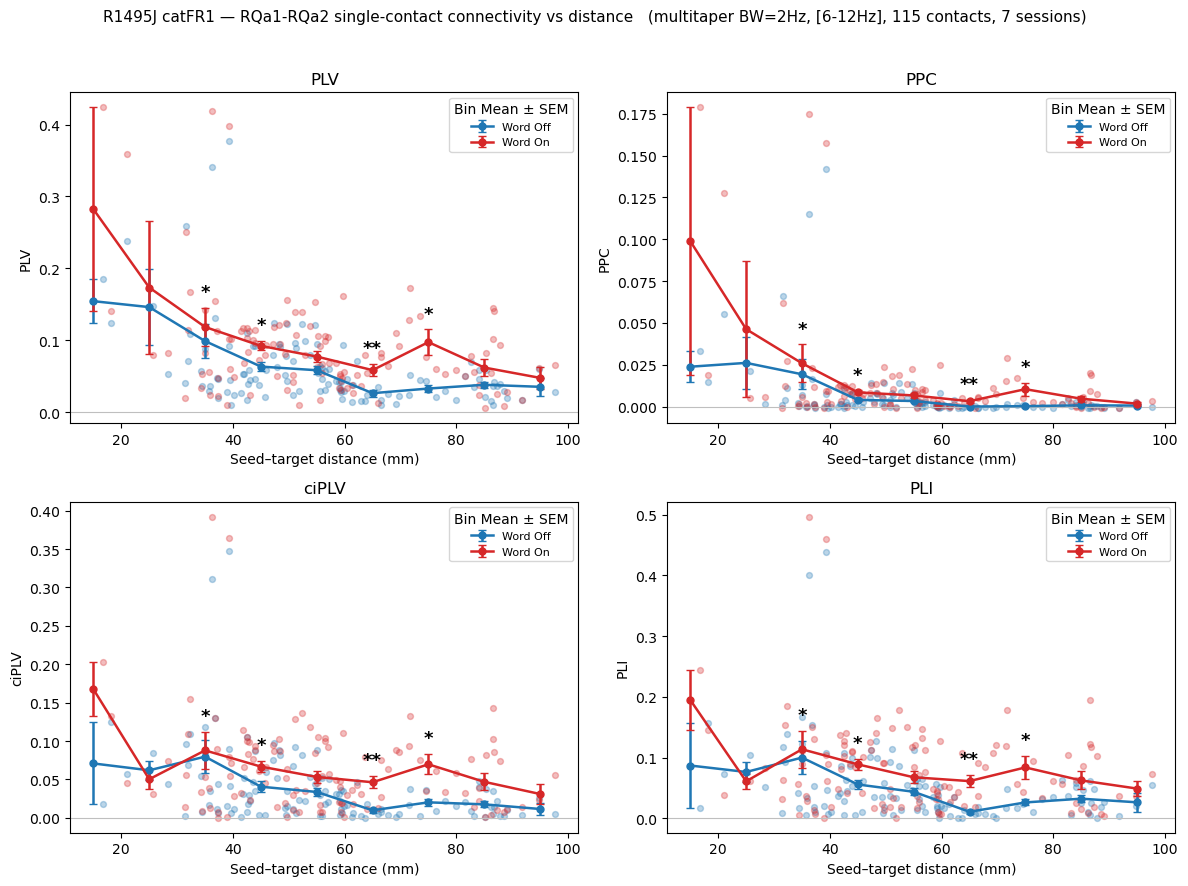

In [11]:
sub, exp     = "R1495J", "catFR1"
seed_label   = "RQa1-RQa2"
fmin, fmax   = (6.0, 12.0)
mt_bandwidth = 2.0
rmin, rmax   = 10.0, 100.0
bin_w        = 10.0
exclude_same_shank = True
pre_win, post_win = (-700., -100.), (0., 600.)
MIN_PAIRS    = 3                       

METRICS = ["PLV", "PPC", "ciPLV", "PLI"]

dfrow = pd.Series({"sub": sub, "exp": exp, "sess": 0, "loc": 0, "mon": 0})
p0   = helper.get_pairs(dfrow)
xyz  = p0[["mni.x", "mni.y", "mni.z"]].apply(pd.to_numeric, errors="coerce").to_numpy()
lead = p0["label"].str.extract(r"^([A-Za-z]+)")[0]

s         = int(p0.index[p0["label"] == seed_label][0])
seed_lead = lead[s]
seed_c    = fc.contacts_of(seed_label)

targets = []
for j in range(len(p0)):
    if j == s:
        continue
    d = float(np.linalg.norm(xyz[j] - xyz[s]))
    if not (rmin <= d <= rmax) or (contacts_of(p0["label"][j]) & seed_c):
        continue
    same = bool(lead[j] == seed_lead)
    if exclude_same_shank and same:
        continue
    targets.append((j, d, same))

print(p0.loc[s, ["label", "ind.region", "mni.region"]].to_string())
print(f"{seed_label}: {len(targets)} single-contact targets in [{rmin:.0f}-{rmax:.0f}]mm "
      f"({sum(sm for _,_,sm in targets)} same-shank)")

sessions = [ses for ses in range(9)
            if helper.load_events(pd.Series({"sub": sub, "exp": exp, "sess": ses, "loc": 0, "mon": 0}), "word_on") is not None]

ang = {j: {"pre": [], "post": []} for j, _, _ in targets}
for ses in sessions:
    ses_row = pd.Series({"sub": sub, "exp": exp, "sess": ses, "loc": 0, "mon": 0})
    data, t, sf = fc.session_eeg(ses_row, (pre_win[0], post_win[1]))
    for j, _, _ in targets:
        for key, win in [("pre", pre_win), ("post", post_win)]:
            ang[j][key].append(fc.mt_event_angles(data, t, sf, s, [j], win, fmin, fmax, mt_bandwidth))
for j in ang:
    for key in ("pre", "post"):
        ang[j][key] = np.concatenate(ang[j][key])

dists = np.array([d for _, d, _ in targets])
same  = np.array([sm for _, _, sm in targets], bool)
conn  = {key: {m: np.array([conn_from_z(ang[j][key], m) for j, _, _ in targets])
               for m in METRICS} for key in ("pre", "post")}

edges   = np.arange(rmin, rmax + 1e-9, bin_w)
centers = 0.5 * (edges[:-1] + edges[1:])
binidx  = np.clip(np.digitize(dists, edges) - 1, 0, len(centers) - 1)

styles = {"pre": ("Word Off", "tab:blue"), "post": ("Word On", "tab:red")}
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, m in zip(axes.ravel(), METRICS):
    binmean = {}
    for key, (labl, color) in styles.items():
        v = conn[key][m]
        ax.scatter(dists[~same], v[~same], s=18, color=color, alpha=0.30, marker="o")
        ax.scatter(dists[same],  v[same],  s=34, color=color, alpha=0.55, marker="x")
        mean, sem = fc.binstats(v, centers, binidx)
        binmean[key] = (mean, sem)
        ax.errorbar(centers, mean, yerr=sem, color=color, marker="o", ms=5,
                    lw=1.8, capsize=3, label=labl)

    for b in range(len(centers)):
        st = fc.stars(q[b])
        if st:
            y = np.nanmax([binmean["pre"][0][b], binmean["post"][0][b]])
            e = np.nanmax([np.nan_to_num(binmean["pre"][1][b]),
                           np.nan_to_num(binmean["post"][1][b])])
            ax.annotate(st, (centers[b], y + e), textcoords="offset points",
                        xytext=(0, 5), ha="center", va="bottom",
                        fontsize=13, fontweight="bold", color="k")

    ax.axhline(0, color="0.75", lw=0.8)
    ax.set_title(m); ax.set_xlabel("Seed–target distance (mm)"); ax.set_ylabel(m)
    ax.legend(fontsize=8, title="Bin Mean ± SEM")
fig.suptitle(f"{sub} {exp} — {seed_label} single-contact connectivity vs distance   "
             f"(multitaper BW={mt_bandwidth:g}Hz, [{fmin:g}-{fmax:g}Hz], "
             f"{len(targets)} contacts, {len(sessions)} sessions)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


label                         RQa1-RQa2
ind.region             inferiortemporal
mni.region     Right FuG fusiform gyrus
RQa1-RQa2: 115 single-contact targets in [10-100]mm (0 same-shank)

Effect (Word On - Word Off) vs distance
   PLV    meanΔ=+0.028  slope b1=+0.009  p(slope)=0.790  r=+0.03
   PPC    meanΔ=+0.006  slope b1=+0.035  p(slope)=0.012  r=+0.23
   ciPLV  meanΔ=+0.024  slope b1=-0.040  p(slope)=0.240  r=-0.11
   PLI    meanΔ=+0.030  slope b1=-0.036  p(slope)=0.402  r=-0.08

[PLV] Word On − Word Off, paired Wilcoxon over pairs (distance-residualized):
    10-20 mm  n= 2  Δmed=+0.128  p=  -    q=  -    ns
    20-30 mm  n=11  Δmed=+0.017  p=0.278  q=0.325  ns
    30-40 mm  n=26  Δmed=+0.024  p=0.000  q=0.001  **
    40-50 mm  n=25  Δmed=+0.019  p=0.001  q=0.003  **
    50-60 mm  n=17  Δmed=+0.020  p=0.064  q=0.089  ns
    60-70 mm  n=11  Δmed=+0.065  p=0.005  q=0.009  **
    70-80 mm  n=17  Δmed=+0.033  p=0.003  q=0.006  **
    80-90 mm  n= 4  Δmed=-0.008  p=0.625  q=0.625  ns
 

/home1/jueenaik/miniforge3/envs/mod_workshop_311/lib/python3.11/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


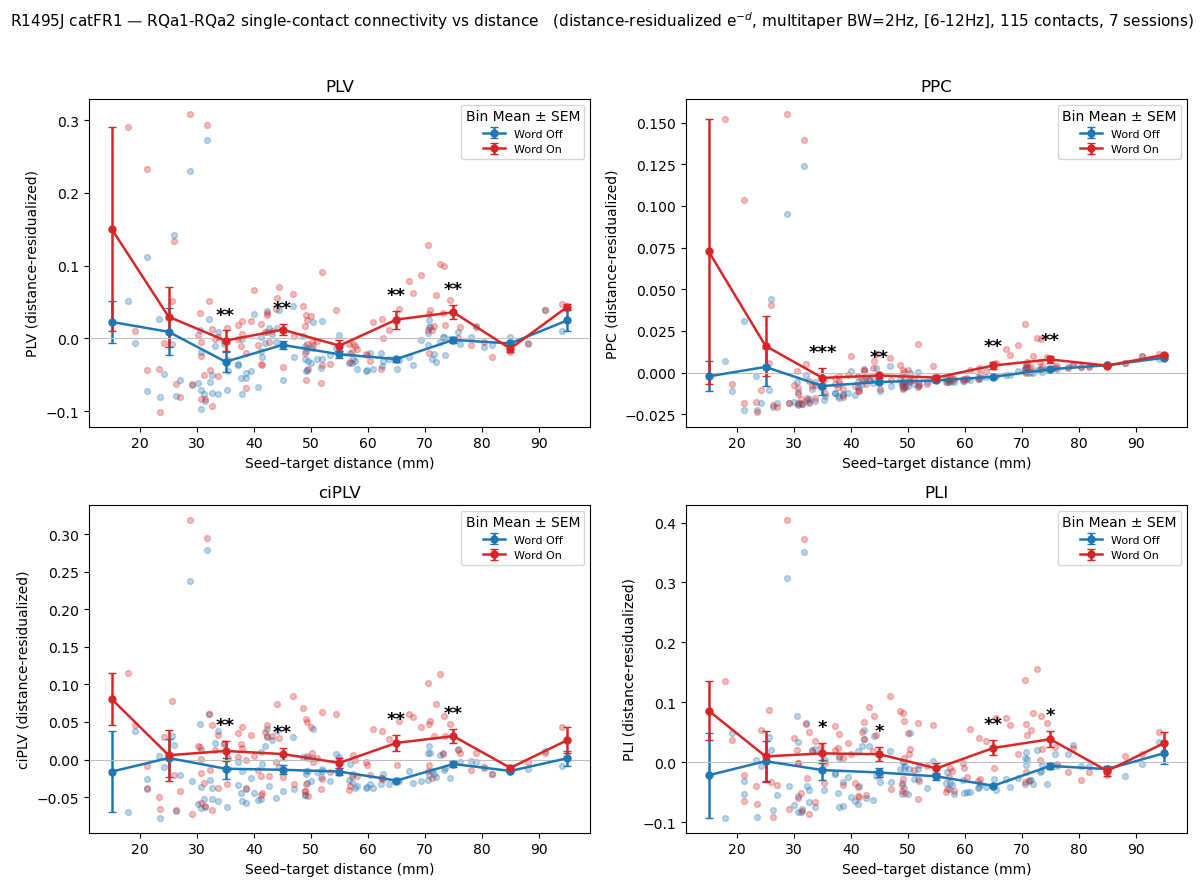

In [ ]:
from scipy.stats import wilcoxon, linregress
from statsmodels.stats.multitest import fdrcorrection

dists = np.array([d for _, d, _ in targets])
same  = np.array([sm for _, _, sm in targets], bool)
conn  = {key: {m: np.array([conn_from_z(ang[j][key], m) for j, _, _ in targets])
               for m in METRICS} for key in ("pre", "post")}


w = np.exp(-dists / dists.max())                          

conn_res = {"pre": {}, "post": {}}
X = np.column_stack([np.ones_like(w), w])
for m in METRICS:
    ys = np.concatenate([conn["pre"][m], conn["post"][m]])
    Xs = np.vstack([X, X])
    ok = np.isfinite(ys)
    beta, *_ = np.linalg.lstsq(Xs[ok], ys[ok], rcond=None)
    for key in ("pre", "post"):
        conn_res[key][m] = conn[key][m] - (beta[0] + beta[1] * w)

print("\nEffect (Word On - Word Off) vs distance")
for m in METRICS:
    dlt = conn["post"][m] - conn["pre"][m]
    ok  = np.isfinite(dlt)
    lr  = linregress(w[ok], dlt[ok])
    print(f"   {m:5s}  meanΔ={np.nanmean(dlt):+.3f}  slope b1={lr.slope:+.3f}  "
          f"p(slope)={lr.pvalue:.3f}  r={lr.rvalue:+.2f}")

edges   = np.arange(rmin, rmax + 1e-9, bin_w)
centers = 0.5 * (edges[:-1] + edges[1:])
binidx  = np.clip(np.digitize(dists, edges) - 1, 0, len(centers) - 1)

def binstats(v):
    mean = np.full(len(centers), np.nan); sem = np.full(len(centers), np.nan)
    for b in range(len(centers)):
        vv = v[(binidx == b) & np.isfinite(v)]
        if vv.size:
            mean[b] = vv.mean()
            if vv.size > 1:
                sem[b] = vv.std(ddof=1) / np.sqrt(vv.size)
    return mean, sem


styles = {"pre": ("Word Off", "tab:blue"), "post": ("Word On", "tab:red")}
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, m in zip(axes.ravel(), METRICS):
    binmean = {}
    for key, (labl, color) in styles.items():
        v = conn_res[key][m]
        ax.scatter(dists[~same], v[~same], s=18, color=color, alpha=0.30, marker="o")
        ax.scatter(dists[same],  v[same],  s=34, color=color, alpha=0.55, marker="x")
        mean, sem = binstats(v)
        binmean[key] = (mean, sem)
        ax.errorbar(centers, mean, yerr=sem, color=color, marker="o", ms=5,
                    lw=1.8, capsize=3, label=labl)

    p_raw, q, npair, dmed = bin_wilcoxon(m)
    print(f"\n[{m}] Word On − Word Off, paired Wilcoxon over pairs (distance-residualized):")
    for b in range(len(centers)):
        if npair[b]:
            st = stars(q[b]) or "ns"
            praw_s = f"{p_raw[b]:.3f}" if np.isfinite(p_raw[b]) else "  -  "
            q_s    = f"{q[b]:.3f}"     if np.isfinite(q[b])     else "  -  "
            print(f"   {int(edges[b]):>3}-{int(edges[b+1]):<3}mm  n={npair[b]:>2}  "
                  f"Δmed={dmed[b]:+.3f}  p={praw_s}  q={q_s}  {st}")

    for b in range(len(centers)):
        st = stars(q[b])
        if st:
            y = np.nanmax([binmean["pre"][0][b], binmean["post"][0][b]])
            e = np.nanmax([np.nan_to_num(binmean["pre"][1][b]),
                           np.nan_to_num(binmean["post"][1][b])])
            ax.annotate(st, (centers[b], y + e), textcoords="offset points",
                        xytext=(0, 5), ha="center", va="bottom",
                        fontsize=13, fontweight="bold", color="k")

    ax.axhline(0, color="0.75", lw=0.8)
    ax.set_title(m); ax.set_xlabel("Seed–target distance (mm)")
    ax.set_ylabel(f"{m} (distance-residualized)")
    ax.legend(fontsize=8, title="Bin Mean ± SEM")
fig.suptitle(f"{sub} {exp} — {seed_label} single-contact connectivity vs distance   "
             f"(distance-residualized e$^{{-d}}$, multitaper BW={mt_bandwidth:g}Hz, "
             f"[{fmin:g}-{fmax:g}Hz], {len(targets)} contacts, {len(sessions)} sessions)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [13]:
import pandas as pd, burke_roi_connectivity as b, helper
pd.set_option("display.max_rows", 300)

sub, exp = "R1495J", "catFR1"
lobe_of, _ = b._load_burke_maps()
p0 = helper.get_pairs(pd.Series({"sub":sub,"exp":exp,"sess":0,"loc":0,"mon":0}))
p0 = b.assign_rois(p0, lobe_of, sub=sub, exp=exp)   

table = p0[["label","type_1","_src","ind.region","mni.region",
            "_region","_lobe","_hemi","_roi"]].rename(columns={
    "label":"electrode","type_1":"type","_src":"label_from_atlas",
    "_region":"std_region","_lobe":"burke_lobe","_hemi":"hemi","_roi":"burke_ROI"})
display(table)

print(p0["_roi"].value_counts(dropna=False).to_string())
print("\nUnassigned (mostly white matter):")
display(p0[p0["_roi"].isna()][["label","type_1","_src","ind.region","mni.region","_region"]])


,electrode,type,label_from_atlas,ind.region,mni.region,std_region,burke_lobe,hemi,burke_ROI
0,Ri1-Ri2,D,mni.region,insula,Right PIns posterior insula,insula,limbic,R,R-limbic
1,Ri2-Ri3,D,mni.region,insula,Right PIns posterior insula,insula,limbic,R,R-limbic
2,Ri3-Ri4,D,mni.region,insula,Right PIns posterior insula,insula,limbic,R,R-limbic
3,Ri4-Ri5,D,mni.region,insula,Right PIns posterior insula,insula,limbic,R,R-limbic
4,Ri5-Ri6,D,mni.region,insula,Right Cerebral White Matter,nan,,None,None
5,Ri6-Ri7,D,mni.region,insula,Right PIns posterior insula,insula,limbic,R,R-limbic
6,Ri7-Ri8,D,no atlas,nan,nan,nan,,None,None
7,Ri8-Ri9,D,no atlas,nan,nan,nan,,None,None
8,Ri9-Ri10,D,mni.region,insula,Right PIns posterior insula,insula,limbic,R,R-limbic
9,Ri10-Ri11,D,mni.region,insula,Right PIns posterior insula,insula,limbic,R,R-limbic


_roi
None           78
R-limbic       18
R-frontal      11
R-temporal      7
R-parietal      7
R-occipital     3

Unassigned (mostly white matter):


,label,type_1,_src,ind.region,mni.region,_region
4,Ri5-Ri6,D,mni.region,insula,Right Cerebral White Matter,nan
6,Ri7-Ri8,D,no atlas,nan,nan,nan
7,Ri8-Ri9,D,no atlas,nan,nan,nan
19,Rm9-Rm10,D,mni.region,precentral,Right Cerebral White Matter,nan
22,Rk3-Rk4,D,mni.region,insula,Right Cerebral White Matter,nan
29,ROb3-ROb4,D,mni.region,lateralorbitofrontal,Right Cerebral White Matter,nan
30,ROb4-ROb5,D,mni.region,lateralorbitofrontal,Right Cerebral White Matter,nan
31,ROb6-ROb7,D,mni.region,insula,Right Cerebral White Matter,nan
32,ROb7-ROb8,D,mni.region,insula,Right Cerebral White Matter,nan
33,ROb8-ROb9,D,mni.region,insula,Right Cerebral White Matter,nan


In [ ]:
# single contact - single contact
# 1. connectivity with distance excluding same-shank
# 2. same-shank x distance vs different-shank same-distance stats BOOTSTRAPPED over different contacts
# averaged connectivity over varying numbers of pairs
# averaged "" over varying numbers of subjects (subsampled) for single region-region pair

label                         RQa1-RQa2
ind.region             inferiortemporal
mni.region     Right FuG fusiform gyrus
CPP total time wavelet loop:  2.4661238193511963
CPP total time wavelet loop:  2.5052523612976074
CPP total time wavelet loop:  2.5822041034698486
CPP total time wavelet loop:  2.491316080093384
CPP total time wavelet loop:  2.649527072906494
CPP total time wavelet loop:  2.5049729347229004
CPP total time wavelet loop:  2.6658124923706055


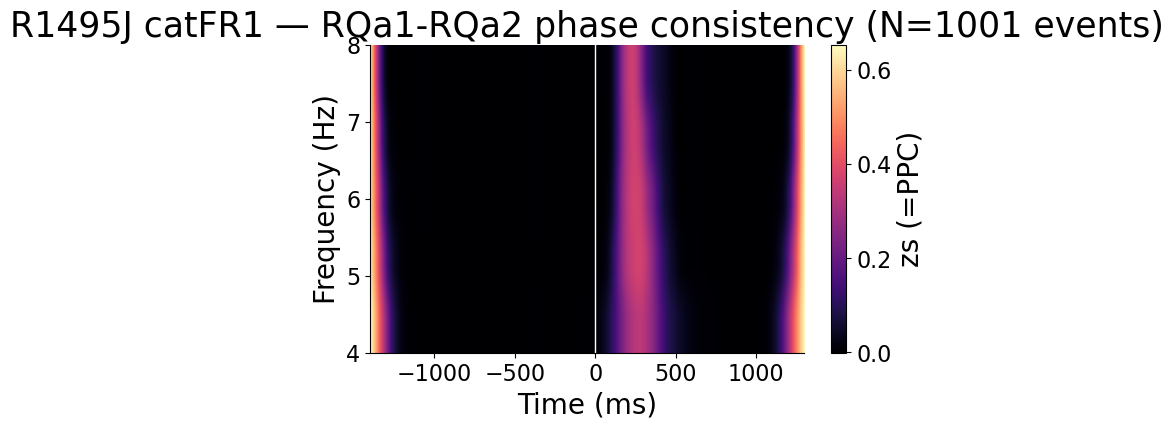


Word-Off zs=0.0006   Word-On zs=0.1613   Δ=+0.1607   p=2.00e-03   (theta, N=1001 events)


In [ ]:
import cstat

sub, exp   = "R1495J", "catFR1"
contact_label = "RQa1-RQa2"
FREQS      = np.arange(4, 9)         
theta_freqs= np.asarray(fc.bands["theta"], float)
morlet_width = 3                        
epoch_win  = (-750., 750.)
buffer_ms  = 700.
pre_win, post_win = (-700., -100.), (0., 600.)   

dfrow = pd.Series({"sub": sub, "exp": exp, "sess": 0, "loc": 0, "mon": 0})
p0    = helper.get_pairs(dfrow)
cidx  = p0.index[p0["label"] == contact_label][0]
print(p0.loc[cidx, ["label", "ind.region", "mni.region"]].to_string())

sessions = [s for s in range(9)
            if helper.load_events(pd.Series({"sub": sub, "exp": exp, "sess": s, "loc": 0, "mon": 0}), "word_on") is not None]

blocks = []
for ses in sessions:
    ses_row = pd.Series({"sub": sub, "exp": exp, "sess": ses, "loc": 0, "mon": 0})
    phase, t = fc.session_phase(ses_row, pre_win, post_win, buffer_ms, FREQS, morlet_width)
    blocks.append(phase[:, cidx])                 
phase_ev = np.concatenate(blocks, axis=0)         
N = phase_ev.shape[0]

def zs_map(ph):                                   
    n = ph.shape[0]
    R = np.abs(np.exp(1j * ph).mean(axis=0))      
    return (n * R * R - 1) / (n - 1)              

pc = zs_map(phase_ev)                             

extent = [t[0], t[-1], FREQS[0], FREQS[-1]]
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pc, origin="lower", aspect="auto", extent=extent, cmap="magma")
ax.axvline(0, color="w", lw=1); ax.set_xlabel("Time (ms)"); ax.set_ylabel("Frequency (Hz)")
#ax.set_title(f"{sub} {exp} — {contact_label} phase consistency (N={N} events)")
fig.colorbar(im, ax=ax, label="PPC"); plt.show()

fmask = np.isin(FREQS, np.round(theta_freqs).astype(int))   
mpre  = (t >= pre_win[0])  & (t <= pre_win[1])
mpost = (t >= post_win[0]) & (t <= post_win[1])
L = min(mpre.sum(), mpost.sum())
pre  = phase_ev[:, fmask][..., np.where(mpre)[0][:L]]        
post = phase_ev[:, fmask][..., np.where(mpost)[0][:L]]

def windowed_zs(ph):                              
    return np.nanmean(zs_map(ph))

off_obs, on_obs = windowed_zs(pre), windowed_zs(post)
d_obs = on_obs - off_obs

rng, n_perm, ge = np.random.default_rng(0), 500, 1
for _ in range(n_perm):
    sw = (rng.random(N) < 0.5)[:, None, None]
    d = windowed_zs(np.where(sw, pre, post)) - windowed_zs(np.where(sw, post, pre))
    if abs(d) >= abs(d_obs): ge += 1
p = ge / (n_perm + 1)

print(f"\nWord-Off zs={off_obs:.4f}   Word-On zs={on_obs:.4f}   "
      f"Δ={d_obs:+.4f}   p={p:.2e}   (theta, N={N} events)")

label                         RQa1-RQa2
ind.region             inferiortemporal
mni.region     Right FuG fusiform gyrus


/tmp/ipykernel_503381/3504217907.py:22: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  X, freqs, w = psd_array_multitaper(
/tmp/ipykernel_503381/3504217907.py:22: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  X, freqs, w = psd_array_multitaper(
/tmp/ipykernel_503381/3504217907.py:22: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  X, freqs, w = psd_array_multitaper(
/tmp/ipykernel_503381/3504217907.py:22: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  X, freqs, w = psd_array_multitaper(
/tmp/ipykernel_503381/3504217907.py:22: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  X, freqs, w = psd_array_multitaper(
/tmp/ipykernel_503381/3504217907.py:22: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  X, freqs, w = psd_array_multitaper(
/tmp/ipykernel_503381/3504217907.py:22: RuntimeWarning: Could not properly use low

Word-Off PPC=-0.0008   Word-On PPC=0.0279   ΔPPC=+0.0287   p=5.00e-04   (theta [6-12Hz], N=1001)


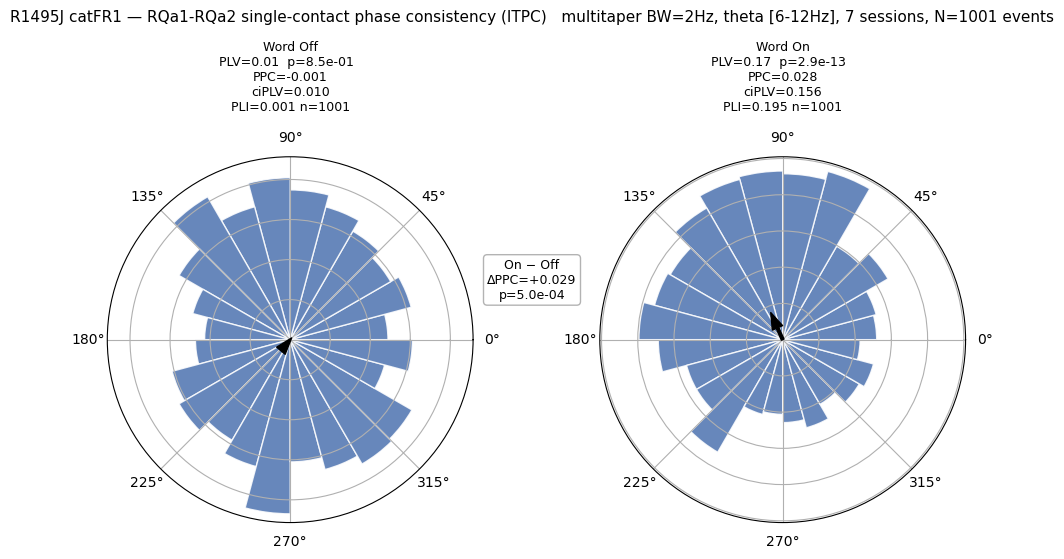

In [12]:
import cstat
from mne.time_frequency import psd_array_multitaper

sub, exp      = "R1495J", "catFR1"
contact_label = "RQa1-RQa2"
fmin, fmax    = (6.0, 12.0)
mt_bandwidth  = 2.0
pre_win, post_win = (-700., -100.), (0., 600.)
n_bins  = 24
n_perm  = 2000

dfrow = pd.Series({"sub": sub, "exp": exp, "sess": 0, "loc": 0, "mon": 0})
p0    = helper.get_pairs(dfrow)
cidx  = int(p0.index[p0["label"] == contact_label][0])
print(p0.loc[cidx, ["label", "ind.region", "mni.region"]].to_string())

sessions = [s for s in range(9)
            if helper.load_events(pd.Series({"sub": sub, "exp": exp, "sess": s, "loc": 0, "mon": 0}), "word_on") is not None]

def mt_event_phase(data, t, sf, ch, win, fmin, fmax, bandwidth=mt_bandwidth):
    m = (t >= win[0]) & (t <= win[1])
    X, freqs, w = psd_array_multitaper(
        data[:, [ch], m], sf, fmin=fmin, fmax=fmax, bandwidth=bandwidth,
        adaptive=False, low_bias=True, output="complex", verbose=False)
    return np.angle((w * X).sum(axis=-2).mean(1))     

ph = {"pre": [], "post": []}
for ses in sessions:
    ses_row = pd.Series({"sub": sub, "exp": exp, "sess": ses, "loc": 0, "mon": 0})
    data, t, sf = fc.session_eeg(ses_row, (pre_win[0], post_win[1]))
    ph["pre"].append(mt_event_phase(data, t, sf, cidx, pre_win,  fmin, fmax))
    ph["post"].append(mt_event_phase(data, t, sf, cidx, post_win, fmin, fmax))
ph = {k: np.concatenate(v) for k, v in ph.items()}
N = ph["pre"].size

off_obs, on_obs = float(cstat.ppc(ph["pre"])), float(cstat.ppc(ph["post"]))
d_obs = on_obs - off_obs
rng, ge = np.random.default_rng(0), 1
for _ in range(n_perm):
    sw = rng.random(N) < 0.5
    a = np.where(sw, ph["pre"], ph["post"]); b = np.where(sw, ph["post"], ph["pre"])
    if abs(float(cstat.ppc(a)) - float(cstat.ppc(b))) >= abs(d_obs):
        ge += 1
p = ge / (n_perm + 1)
print(f"Word-Off PPC={off_obs:.4f}   Word-On PPC={on_obs:.4f}   "
      f"ΔPPC={d_obs:+.4f}   p={p:.2e}   (theta [{fmin:g}-{fmax:g}Hz], N={N})")

fig, axes = plt.subplots(1, 2, figsize=(10, 5.2), subplot_kw={"projection": "polar"})
cstat.rose(axes[0], ph["pre"],  "Word Off", n_bins, True)
cstat.rose(axes[1], ph["post"], "Word On",  n_bins, True)
fig.suptitle(f"{sub} {exp} — {contact_label} single-contact phase consistency (ITPC)   "
             f"multitaper BW={mt_bandwidth:g}Hz, theta [{fmin:g}-{fmax:g}Hz], "
             f"{len(sessions)} sessions, N={N} events", y=1.02, fontsize=11)
fig.tight_layout()
fig.text(0.5, 0.5, f"On − Off\nΔPPC={d_obs:+.3f}\np={p:.1e}", ha="center", va="center",
         fontsize=9, bbox=dict(boxstyle="round", fc="white", ec="0.7"))
plt.show()

label                         RQa2-RQa3
ind.region             inferiortemporal
mni.region     Right FuG fusiform gyrus
CPP total time wavelet loop:  2.4442789554595947
CPP total time wavelet loop:  2.591414213180542
CPP total time wavelet loop:  2.481952428817749
CPP total time wavelet loop:  4.213908910751343
CPP total time wavelet loop:  4.478933334350586
CPP total time wavelet loop:  2.634554147720337
CPP total time wavelet loop:  2.5581302642822266


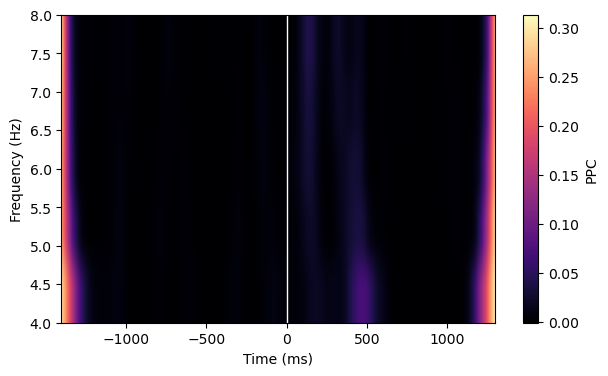


Word-Off zs=0.0017   Word-On zs=0.0255   Δ=+0.0238   p=2.00e-03   (theta, N=1001 events)


In [16]:
import cstat

sub, exp   = "R1495J", "catFR1"
contact_label = "RQa2-RQa3"
FREQS      = np.arange(4, 9)         
theta_freqs= np.asarray(fc.bands["theta"], float)
morlet_width = 3                        
epoch_win  = (-750., 750.)
buffer_ms  = 700.
pre_win, post_win = (-700., -100.), (0., 600.)   

dfrow = pd.Series({"sub": sub, "exp": exp, "sess": 0, "loc": 0, "mon": 0})
p0    = helper.get_pairs(dfrow)
cidx  = p0.index[p0["label"] == contact_label][0]
print(p0.loc[cidx, ["label", "ind.region", "mni.region"]].to_string())

sessions = [s for s in range(9)
            if helper.load_events(pd.Series({"sub": sub, "exp": exp, "sess": s, "loc": 0, "mon": 0}), "word_on") is not None]

blocks = []
for ses in sessions:
    ses_row = pd.Series({"sub": sub, "exp": exp, "sess": ses, "loc": 0, "mon": 0})
    phase, t = fc.session_phase(ses_row, pre_win, post_win, buffer_ms, FREQS, morlet_width)
    blocks.append(phase[:, cidx])                 
phase_ev = np.concatenate(blocks, axis=0)         
N = phase_ev.shape[0]

def zs_map(ph):                                   
    n = ph.shape[0]
    R = np.abs(np.exp(1j * ph).mean(axis=0))      
    return (n * R * R - 1) / (n - 1)              

pc = zs_map(phase_ev)                             

extent = [t[0], t[-1], FREQS[0], FREQS[-1]]
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pc, origin="lower", aspect="auto", extent=extent, cmap="magma")
ax.axvline(0, color="w", lw=1); ax.set_xlabel("Time (ms)"); ax.set_ylabel("Frequency (Hz)")
#ax.set_title(f"{sub} {exp} — {contact_label} phase consistency (N={N} events)")
fig.colorbar(im, ax=ax, label="PPC"); plt.show()

fmask = np.isin(FREQS, np.round(theta_freqs).astype(int))   
mpre  = (t >= pre_win[0])  & (t <= pre_win[1])
mpost = (t >= post_win[0]) & (t <= post_win[1])
L = min(mpre.sum(), mpost.sum())
pre  = phase_ev[:, fmask][..., np.where(mpre)[0][:L]]        
post = phase_ev[:, fmask][..., np.where(mpost)[0][:L]]

def windowed_zs(ph):                              
    return np.nanmean(zs_map(ph))

off_obs, on_obs = windowed_zs(pre), windowed_zs(post)
d_obs = on_obs - off_obs

rng, n_perm, ge = np.random.default_rng(0), 500, 1
for _ in range(n_perm):
    sw = (rng.random(N) < 0.5)[:, None, None]
    d = windowed_zs(np.where(sw, pre, post)) - windowed_zs(np.where(sw, post, pre))
    if abs(d) >= abs(d_obs): ge += 1
p = ge / (n_perm + 1)

print(f"\nWord-Off zs={off_obs:.4f}   Word-On zs={on_obs:.4f}   "
      f"Δ={d_obs:+.4f}   p={p:.2e}   (theta, N={N} events)")